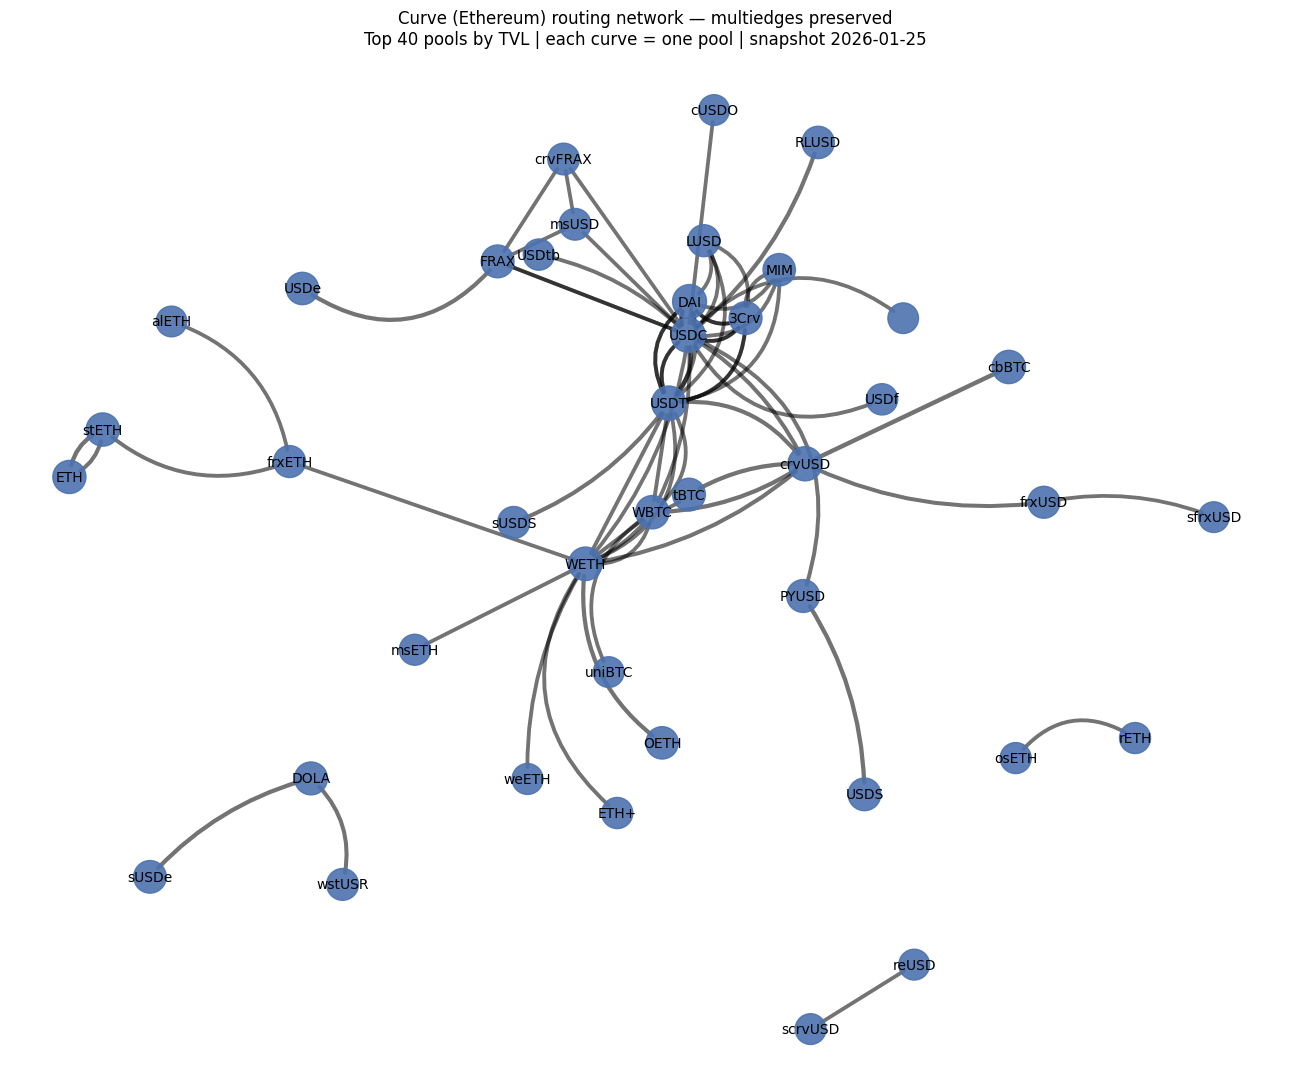

In [ ]:
# Multi-edge (pool-specific) token network visualization for Curve snapshot
# Input: the original snapshot CSV you shared (one row per pool)
#
# Output: a PNG where
# - nodes = tokens
# - each curved edge = one specific pool (multi-edges preserved)
# - edge width ~ log(TVL)
# - node size ~ TVL-weighted degree
# - only top N pools by TVL (to stay readable)

import re
import ast
import math
from itertools import combinations
from pathlib import Path

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
SNAPSHOT_CSV = "../data/curve_pool_snapshot_24h_ethereum_2026-01-25T13_44_33.9443838Z.csv"
TOP_POOLS = 40          # keep only top pools by TVL for a readable figure
TOP_LABELS = 40         # label only the most central tokens
FIGSIZE = (13, 11)
SEED = 13               # determinism for layout

# -------------------------
# HELPERS
# -------------------------
def parse_quoted_list(x):
    """
    Parse Postgres/Metabase array-ish strings like:
      {"DAI","USDC","USDT"}
    into ["DAI","USDC","USDT"].
    Works for addresses too.
    """
    if pd.isna(x):
        return []
    return re.findall(r'"([^"]+)"', str(x))

def parse_numeric_list(x):
    """
    Parse strings like:
      [1,2,3] or [1.2e+25, 123, ...]
    into Python list[float].
    """
    if pd.isna(x):
        return []
    s = str(x).strip()
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple)):
            return list(val)
    except Exception:
        pass
    nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
    return [float(n) for n in nums]

# -------------------------
# LOAD + PARSE
# -------------------------
df = pd.read_csv(SNAPSHOT_CSV)

# Expect these columns from your snapshot query:
# token_symbols_by_index, tvl_usd, pool_id, pool_address, pool_type, pool_symbol
df["token_syms"] = df["token_symbols_by_index"].apply(parse_quoted_list)
df["tvl_usd_num"] = pd.to_numeric(df["tvl_usd"], errors="coerce")

# Keep only pools where we successfully parsed >= 2 tokens
df = df[df["token_syms"].apply(len) >= 2].copy()

# Take top pools by TVL (otherwise a hairball)
df_top = df.sort_values("tvl_usd_num", ascending=False).head(TOP_POOLS)

# -------------------------
# BUILD MULTIGRAPH
# -------------------------
G = nx.MultiGraph()

for _, r in df_top.iterrows():
    tokens = r["token_syms"]
    pool_id = int(r["pool_id"])
    tvl = float(r["tvl_usd_num"]) if not pd.isna(r["tvl_usd_num"]) else 0.0

    # Pool metadata (kept as edge attributes)
    attrs = dict(
        pool_id=pool_id,
        pool_address=r.get("pool_address", None),
        pool_symbol=r.get("pool_symbol", None),
        pool_type=r.get("pool_type", None),
        tvl_usd=tvl,
    )

    # For n-coin pools, add all pairwise edges (clique expansion)
    for i, j in combinations(range(len(tokens)), 2):
        u, v = tokens[i], tokens[j]
        # key=pool_id preserves multi-edges per pool across pairs (fine for viz)
        G.add_edge(u, v, key=pool_id, **attrs)

# -------------------------
# LAYOUT (SPREAD OUT NODES)
# -------------------------
# Increase k to add repulsion and "space out" nodes
pos = nx.spring_layout(
    G,
    seed=SEED,
    k=10 / math.sqrt(max(1, G.number_of_nodes())),
    iterations=200,
)

# -------------------------
# SIZING + LABELS
# -------------------------
# Node size by TVL-weighted degree (sum TVL of incident edges)
wdeg = {}
for n in G.nodes():
    s = 0.0
    for _, _, d in G.edges(n, data=True):
        s += float(d.get("tvl_usd", 0.0) or 0.0)
    wdeg[n] = s

node_sizes = [max(120.0, math.log1p(wdeg[n]) * 30.0) for n in G.nodes()]

# Label only top tokens (prevents clutter)
top_nodes = set(sorted(wdeg, key=wdeg.get, reverse=True)[:TOP_LABELS])
labels = {n: n for n in top_nodes}

# -------------------------
# DRAW
# -------------------------
plt.figure(figsize=FIGSIZE)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color="#4C72B0",   # feel free to change
    alpha=0.90
)

# Draw multi-edges with curvature; different curvature per pool_id so parallels separate
for (u, v, key, data) in G.edges(keys=True, data=True):
    # deterministic curvature from pool_id; gives a small set of distinct arcs
    # (keeps it stable across runs)
    rad = 0.15 * ((hash(key) % 7) - 3)  # values in {-0.45,...,0.45}
    width = max(0.8, math.log1p(float(data.get("tvl_usd", 0.0))) / 6.0)

    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        width=width,
        alpha=0.55,
        edge_color="black",
        connectionstyle=f"arc3,rad={rad}",
    )

# Labels
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

snap = df_top["snapshot_date"].iloc[0] if "snapshot_date" in df_top.columns else ""
plt.title(
    "Curve (Ethereum) routing network — multiedges preserved\n"
    f"Top {TOP_POOLS} pools by TVL | each curve = one pool"
    + (f" | snapshot {snap}" if snap else "")
)
plt.axis("off")
plt.tight_layout()
plt.show()




Loaded snapshot pools: 325 (snapshot_date=2026-01-25)
MultiGraph: nodes=217 edges(pool-edges)=719
Aggregated Graph: nodes=217 edges(token-pairs)=485

=== QUICK READOUT (PRINT) ===

Basic:
- Tokens: 217
- Pool-edges (multigraph): 719
- Token-pairs (aggregated): 485
- Aggregated density: 0.020695
- GCC nodes: 211 (97.2%)
- GCC TVL-edge-weight share: 99.6%

Top tokens by TVL-strength:
 token  strength_tvl  degree
  USDC  7.812006e+08      78
  USDT  6.576878e+08      44
crvUSD  6.277457e+08      35
   DAI  4.632052e+08      30
  WETH  3.278059e+08      51
  WBTC  2.472987e+08      23
 cbBTC  2.400464e+08       8
 stETH  1.887074e+08       5
   ETH  1.807009e+08       5
  DOLA  1.442955e+08      16
  3Crv  1.340555e+08      19
  FRAX  1.313446e+08      33
 PYUSD  1.287024e+08       6
  tBTC  1.254979e+08       7
 sUSDe  1.186162e+08      11

Top token pairs by summed TVL:
token_u token_v   weight_tvl  pool_count
 crvUSD   cbBTC 2.056976e+08           1
   USDT    USDC 2.042482e+08        

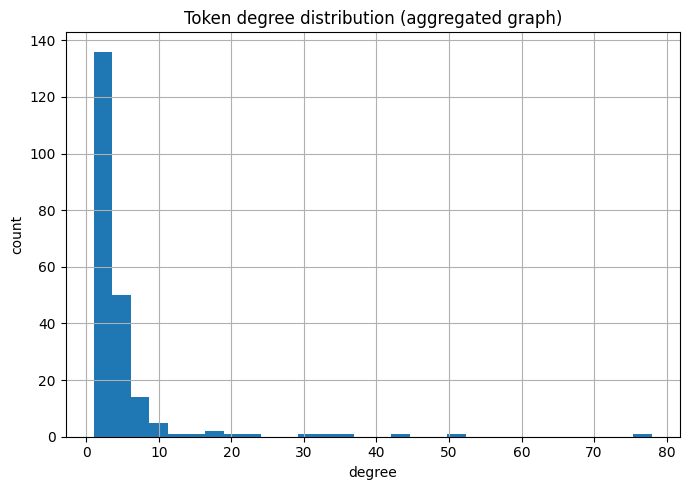

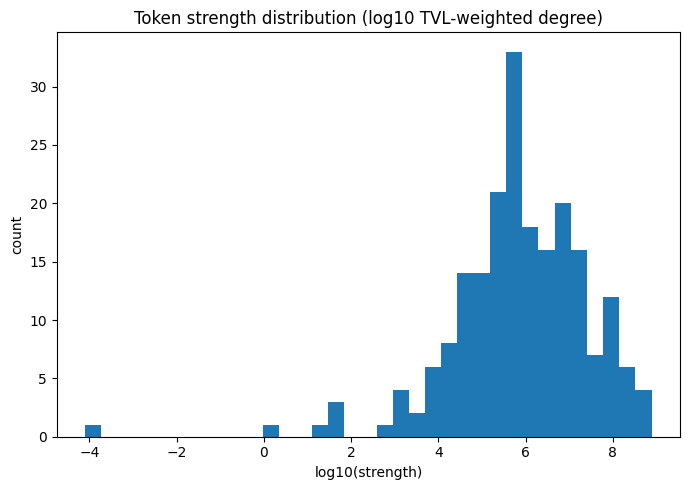

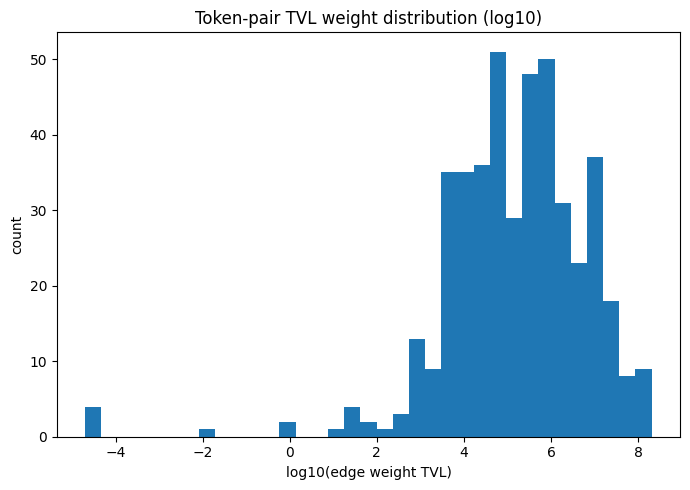

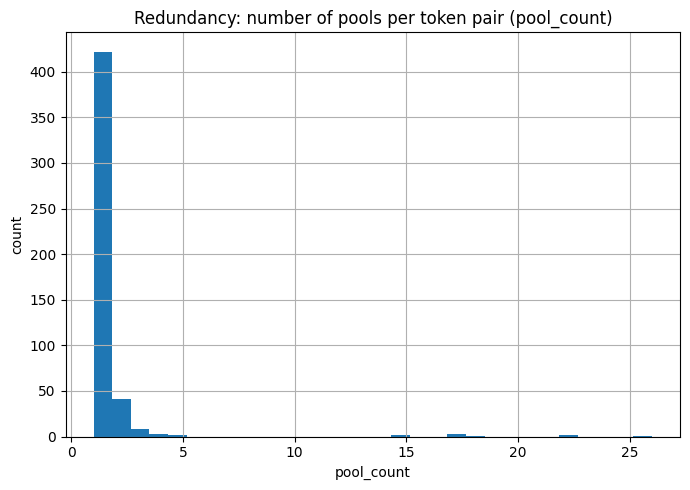

In [8]:
"""
Curve liquidity network — full descriptive analysis from the ORIGINAL uploaded snapshot CSV.

Inputs
------
- The original one-row-per-pool snapshot CSV you uploaded:
  /mnt/data/curve_pool_snapshot_24h_ethereum_2026-01-25T13_44_33.9443838Z.csv

What this script does
---------------------
1) Parses token lists + per-token reserves from the snapshot.
2) Builds:
   - MultiGraph G: tokens are nodes; each pool induces MULTI-EDGES between all token pairs in the pool
     (edge attributes include pool_id, pool_address, pool_type, pool_symbol, A, fee_raw, tvl_usd,
      and per-endpoint reserves for that pair-edge).
   - Aggregated Graph H: collapses multi-edges; one edge per token pair with:
       weight_tvl = sum TVL of pools connecting the pair
       pool_count = number of distinct pools connecting the pair
3) Prints standard descriptive metrics we discussed:
   - Size, connected components, GCC size + GCC TVL share
   - Density (on H / GCC)
   - Degree + TVL-strength distributions (summaries)
   - Concentration: top-k strength share + HHI
   - Edge-weight distribution (pair TVL weights)
   - Redundancy: pool_count distribution + top redundant pairs
   - Assortativity (degree assortativity on H)
   - k-core decomposition (core numbers; top core tokens)
   - Betweenness centrality (top nodes, computed on GCC of H; topological)
   - Clustering coefficient (with caveat: clique expansion inflates triangles)
4) Saves:
   - metrics summary CSV
   - top tokens CSV
   - top pairs CSV
   - optional plots (degree/strength hist, edge-weight hist)

Notes / pitfalls to be aware of
-------------------------------
- Multi-coin pools are represented via clique expansion. This is standard for routing connectivity,
  but it inflates clustering and triangle counts. Treat clustering as descriptive only.
- fee_raw and A are taken as-is from your snapshot table. fee scaling depends on pool implementation.
"""

from __future__ import annotations

import ast
import math
import re
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# -------------------------
# CONFIG
# -------------------------
SNAPSHOT_CSV = Path(
    "../data/curve_pool_snapshot_24h_ethereum_2026-01-25T13_44_33.9443838Z.csv"
)

OUT_DIR = Path("../data")
OUT_PREFIX = "curve_network_full_ethereum_2026-01-25"

MAKE_PLOTS = True  # set False if you only want tables + printouts


# -------------------------
# HELPERS
# -------------------------
def parse_quoted_list(x: Any) -> List[str]:
    """
    Parse Postgres/Metabase style arrays like {"DAI","USDC","USDT"}.
    Returns [] if missing.
    """
    if pd.isna(x):
        return []
    return re.findall(r'"([^"]+)"', str(x))


def parse_numeric_list(x: Any) -> List[float]:
    """
    Parse lists like [1.2e+25, 123, ...] or "{...}"-ish numeric strings.
    """
    if pd.isna(x):
        return []
    s = str(x).strip()
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple)):
            return [float(v) for v in val]
    except Exception:
        pass
    nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
    return [float(n) for n in nums]


def to_float(x: Any) -> float:
    try:
        if pd.isna(x):
            return float("nan")
        return float(x)
    except Exception:
        return float("nan")


def to_int(x: Any) -> Optional[int]:
    try:
        if pd.isna(x):
            return None
        return int(float(x))
    except Exception:
        return None


def summarize_numeric(s: pd.Series) -> Dict[str, float]:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return {"count": 0.0}
    return {
        "count": float(len(s)),
        "min": float(s.min()),
        "p25": float(s.quantile(0.25)),
        "median": float(s.median()),
        "p75": float(s.quantile(0.75)),
        "p90": float(s.quantile(0.90)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
        "mean": float(s.mean()),
    }


def hhi_from_shares(shares: pd.Series) -> float:
    shares = pd.to_numeric(shares, errors="coerce").dropna()
    if shares.empty:
        return float("nan")
    return float((shares**2).sum())


def safe_get(lst: List[Any], i: int) -> Any:
    return lst[i] if i < len(lst) else None


# -------------------------
# LOAD + PARSE SNAPSHOT
# -------------------------
df = pd.read_csv(SNAPSHOT_CSV)

# expected columns from your snapshot query
needed = [
    "pool_id",
    "pool_address",
    "pool_type",
    "pool_symbol",
    "pool_name",
    "tvl_usd",
    "a",
    "fee",
    "token_symbols_by_index",
    "token_addresses_by_index",
    "token_ids_by_index",
    "normalized_reserves",
    "reserves",
]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Snapshot CSV missing expected columns: {missing}")

df["tvl_usd_num"] = pd.to_numeric(df["tvl_usd"], errors="coerce")
df["A_num"] = pd.to_numeric(df["a"], errors="coerce")  # may be null for some pool types
df["fee_raw_num"] = pd.to_numeric(df["fee"], errors="coerce")

df["token_syms"] = df["token_symbols_by_index"].apply(parse_quoted_list)
df["token_addrs"] = df["token_addresses_by_index"].apply(parse_quoted_list)
df["token_ids"] = df["token_ids_by_index"].apply(parse_numeric_list)
df["norm_reserves"] = df["normalized_reserves"].apply(parse_numeric_list)
df["raw_reserves"] = df["reserves"].apply(parse_numeric_list)

# keep only pools with >=2 parsed tokens
df = df[df["token_syms"].apply(len) >= 2].copy()

snapshot_date = df["snapshot_date"].iloc[0] if "snapshot_date" in df.columns and len(df) else "unknown"
print(f"\nLoaded snapshot pools: {len(df):,} (snapshot_date={snapshot_date})")


# -------------------------
# BUILD MULTIGRAPH (pool-specific edges preserved)
# -------------------------
G = nx.MultiGraph()

for _, r in df.iterrows():
    pool_id = to_int(r.get("pool_id"))
    if pool_id is None:
        continue

    tokens = r["token_syms"]
    addrs = r["token_addrs"]
    ids = r["token_ids"]
    nres = r["norm_reserves"]
    rres = r["raw_reserves"]

    tvl = to_float(r.get("tvl_usd_num"))
    A = to_float(r.get("A_num"))
    fee_raw = to_float(r.get("fee_raw_num"))

    # per pool metadata
    pool_meta = dict(
        pool_id=pool_id,
        pool_address=r.get("pool_address"),
        pool_type=r.get("pool_type"),
        pool_symbol=r.get("pool_symbol"),
        pool_name=r.get("pool_name"),
        tvl_usd=tvl if not math.isnan(tvl) else 0.0,
        A=A,
        fee_raw=fee_raw,
    )

    # clique expansion: add one edge per token pair in the pool
    for i, j in combinations(range(len(tokens)), 2):
        u = tokens[i]
        v = tokens[j]

        # reserves per endpoint token for THIS pair-edge
        edge_attr = dict(pool_meta)
        edge_attr.update(
            token_i_index=i,
            token_j_index=j,
            token_i_symbol=u,
            token_j_symbol=v,
            token_i_address=safe_get(addrs, i),
            token_j_address=safe_get(addrs, j),
            token_i_id=to_int(safe_get(ids, i)) if safe_get(ids, i) is not None else None,
            token_j_id=to_int(safe_get(ids, j)) if safe_get(ids, j) is not None else None,
            reserve_i_normalized=to_float(safe_get(nres, i)) if safe_get(nres, i) is not None else float("nan"),
            reserve_j_normalized=to_float(safe_get(nres, j)) if safe_get(nres, j) is not None else float("nan"),
            reserve_i_raw=to_float(safe_get(rres, i)) if safe_get(rres, i) is not None else float("nan"),
            reserve_j_raw=to_float(safe_get(rres, j)) if safe_get(rres, j) is not None else float("nan"),
        )

        G.add_edge(u, v, key=pool_id, **edge_attr)

print(f"MultiGraph: nodes={G.number_of_nodes():,} edges(pool-edges)={G.number_of_edges():,}")


# -------------------------
# BUILD AGGREGATED GRAPH (collapse multi-edges)
# -------------------------
H = nx.Graph()
for u, v, data in G.edges(data=True):
    w = float(data.get("tvl_usd", 0.0) or 0.0)
    if H.has_edge(u, v):
        H[u][v]["weight_tvl"] += w
        H[u][v]["pool_count"] += 1
    else:
        H.add_edge(u, v, weight_tvl=w, pool_count=1)

print(f"Aggregated Graph: nodes={H.number_of_nodes():,} edges(token-pairs)={H.number_of_edges():,}")


# -------------------------
# METRICS
# -------------------------
metrics_rows = []

def add_metric(name: str, value: Any):
    metrics_rows.append({"metric": name, "value": value})

# Basic size
add_metric("snapshot_date", snapshot_date)
add_metric("n_tokens", G.number_of_nodes())
add_metric("n_pool_edges_multigraph", G.number_of_edges())
add_metric("n_token_pairs_aggregated", H.number_of_edges())
add_metric("density_aggregated", nx.density(H) if H.number_of_nodes() > 1 else float("nan"))

# Components (aggregated)
components = sorted(nx.connected_components(H), key=len, reverse=True)
add_metric("n_components_aggregated", len(components))
if components:
    gcc_nodes = components[0]
    GCC = H.subgraph(gcc_nodes).copy()
    add_metric("gcc_nodes", GCC.number_of_nodes())
    add_metric("gcc_edges", GCC.number_of_edges())
    add_metric("gcc_density", nx.density(GCC) if GCC.number_of_nodes() > 1 else float("nan"))
    add_metric("gcc_fraction_nodes", GCC.number_of_nodes() / H.number_of_nodes())

    # GCC TVL share: sum weights on GCC edges / sum weights on all edges
    total_edge_weight = sum(H[u][v]["weight_tvl"] for u, v in H.edges()) or 0.0
    gcc_edge_weight = sum(GCC[u][v]["weight_tvl"] for u, v in GCC.edges()) or 0.0
    add_metric("gcc_fraction_edge_weight_tvl", (gcc_edge_weight / total_edge_weight) if total_edge_weight > 0 else float("nan"))
else:
    GCC = H

# Degree and strength
deg = pd.Series(dict(H.degree()), name="degree")
strength = pd.Series(dict(H.degree(weight="weight_tvl")), name="strength_tvl")

deg_summary = summarize_numeric(deg)
strength_summary = summarize_numeric(strength)

for k, v in deg_summary.items():
    add_metric(f"degree_{k}", v)
for k, v in strength_summary.items():
    add_metric(f"strength_tvl_{k}", v)

# Concentration (top-k shares + HHI)
total_strength = strength.sum()
if total_strength > 0:
    shares = strength / total_strength
    for k in [1, 3, 5, 10, 20]:
        add_metric(f"top{k}_strength_share", float(shares.sort_values(ascending=False).head(k).sum()))
    add_metric("hhi_strength", hhi_from_shares(shares))
else:
    add_metric("top5_strength_share", float("nan"))
    add_metric("hhi_strength", float("nan"))

# Edge weight distribution (aggregated)
edge_weights = pd.Series([H[u][v]["weight_tvl"] for u, v in H.edges()], name="edge_weight_tvl")
ew_summary = summarize_numeric(edge_weights)
for k, v in ew_summary.items():
    add_metric(f"edge_weight_tvl_{k}", v)

# Redundancy distribution (pool_count per token pair)
pool_counts = pd.Series([H[u][v]["pool_count"] for u, v in H.edges()], name="pool_count")
pc_summary = summarize_numeric(pool_counts)
for k, v in pc_summary.items():
    add_metric(f"pool_count_{k}", v)

# Assortativity (degree)
try:
    add_metric("degree_assortativity", nx.degree_assortativity_coefficient(H))
except Exception:
    add_metric("degree_assortativity", float("nan"))

# k-core
try:
    core_num = nx.core_number(H) if H.number_of_nodes() > 0 else {}
    if core_num:
        add_metric("max_core_number", max(core_num.values()))
        add_metric("mean_core_number", float(np.mean(list(core_num.values()))))
    else:
        add_metric("max_core_number", float("nan"))
        add_metric("mean_core_number", float("nan"))
except Exception:
    add_metric("max_core_number", float("nan"))
    add_metric("mean_core_number", float("nan"))

# Betweenness (topological) on GCC (unweighted)
# (This is a structural proxy only; not a routing-cost metric.)
try:
    if GCC.number_of_nodes() > 1:
        btw = nx.betweenness_centrality(GCC, normalized=True)  # unweighted
        btw_series = pd.Series(btw, name="betweenness")
        btw_summary = summarize_numeric(btw_series)
        for k, v in btw_summary.items():
            add_metric(f"betweenness_{k}", v)
    else:
        add_metric("betweenness_count", 0.0)
except Exception:
    add_metric("betweenness_count", float("nan"))

# Clustering (caveat: clique expansion inflates triangles)
try:
    if H.number_of_nodes() > 1:
        add_metric("avg_clustering_unweighted", nx.average_clustering(H))
        add_metric("avg_clustering_gcc_unweighted", nx.average_clustering(GCC) if GCC.number_of_nodes() > 1 else float("nan"))
    else:
        add_metric("avg_clustering_unweighted", float("nan"))
        add_metric("avg_clustering_gcc_unweighted", float("nan"))
except Exception:
    add_metric("avg_clustering_unweighted", float("nan"))
    add_metric("avg_clustering_gcc_unweighted", float("nan"))

# Pool-level A, fee coverage
pool_level = df.groupby("pool_id", as_index=False).agg(
    tvl_usd=("tvl_usd_num", "max"),
    pool_type=("pool_type", "first"),
    A=("A_num", "first"),
    fee_raw=("fee_raw_num", "first"),
)
add_metric("n_pools", pool_level["pool_id"].nunique())
add_metric("share_pools_with_A", float(pool_level["A"].notna().mean()))
add_metric("share_pools_with_fee_raw", float(pool_level["fee_raw"].notna().mean()))
for k, v in summarize_numeric(pool_level["A"]).items():
    add_metric(f"A_poollevel_{k}", v)
for k, v in summarize_numeric(pool_level["fee_raw"]).items():
    add_metric(f"fee_raw_poollevel_{k}", v)


# -------------------------
# TABLE OUTPUTS
# -------------------------
metrics_df = pd.DataFrame(metrics_rows)
top_tokens_df = (
    pd.DataFrame({"token": strength.index, "strength_tvl": strength.values, "degree": deg.reindex(strength.index).values})
    .sort_values("strength_tvl", ascending=False)
    .reset_index(drop=True)
)
top_pairs_df = (
    pd.DataFrame(
        {
            "token_u": [u for u, v in H.edges()],
            "token_v": [v for u, v in H.edges()],
            "weight_tvl": [H[u][v]["weight_tvl"] for u, v in H.edges()],
            "pool_count": [H[u][v]["pool_count"] for u, v in H.edges()],
        }
    )
    .sort_values("weight_tvl", ascending=False)
    .reset_index(drop=True)
)

# Redundancy top pairs
top_redundant_pairs_df = top_pairs_df.sort_values("pool_count", ascending=False).head(50).reset_index(drop=True)

# k-core token list
try:
    core_num = nx.core_number(H) if H.number_of_nodes() > 0 else {}
    core_df = (
        pd.DataFrame({"token": list(core_num.keys()), "core_number": list(core_num.values())})
        .sort_values(["core_number", "token"], ascending=[False, True])
        .reset_index(drop=True)
    )
except Exception:
    core_df = pd.DataFrame(columns=["token", "core_number"])

# Betweenness top nodes
try:
    if GCC.number_of_nodes() > 1:
        btw = nx.betweenness_centrality(GCC, normalized=True)
        btw_df = (
            pd.DataFrame({"token": list(btw.keys()), "betweenness": list(btw.values())})
            .sort_values("betweenness", ascending=False)
            .reset_index(drop=True)
        )
    else:
        btw_df = pd.DataFrame(columns=["token", "betweenness"])
except Exception:
    btw_df = pd.DataFrame(columns=["token", "betweenness"])

# # Save tables
# metrics_path = OUT_DIR / f"{OUT_PREFIX}_metrics.csv"
# top_tokens_path = OUT_DIR / f"{OUT_PREFIX}_top_tokens.csv"
# top_pairs_path = OUT_DIR / f"{OUT_PREFIX}_top_pairs_by_tvl.csv"
# top_redundant_pairs_path = OUT_DIR / f"{OUT_PREFIX}_top_pairs_by_poolcount.csv"
# core_path = OUT_DIR / f"{OUT_PREFIX}_kcore_tokens.csv"
# btw_path = OUT_DIR / f"{OUT_PREFIX}_betweenness_topological_gcc.csv"

# metrics_df.to_csv(metrics_path, index=False)
# top_tokens_df.to_csv(top_tokens_path, index=False)
# top_pairs_df.to_csv(top_pairs_path, index=False)
# top_redundant_pairs_df.to_csv(top_redundant_pairs_path, index=False)
# core_df.to_csv(core_path, index=False)
# btw_df.to_csv(btw_path, index=False)

# print("\n=== SAVED FILES ===")
# print(metrics_path)
# print(top_tokens_path)
# print(top_pairs_path)
# print(top_redundant_pairs_path)
# print(core_path)
# print(btw_path)

print("\n=== QUICK READOUT (PRINT) ===")
print("\nBasic:")
print(f"- Tokens: {G.number_of_nodes():,}")
print(f"- Pool-edges (multigraph): {G.number_of_edges():,}")
print(f"- Token-pairs (aggregated): {H.number_of_edges():,}")
print(f"- Aggregated density: {nx.density(H):.6f}" if H.number_of_nodes() > 1 else "- Aggregated density: NA")
if components:
    print(f"- GCC nodes: {GCC.number_of_nodes():,} ({GCC.number_of_nodes()/H.number_of_nodes():.1%})")
    total_edge_weight = sum(H[u][v]['weight_tvl'] for u, v in H.edges()) or 0.0
    gcc_edge_weight = sum(GCC[u][v]['weight_tvl'] for u, v in GCC.edges()) or 0.0
    if total_edge_weight > 0:
        print(f"- GCC TVL-edge-weight share: {gcc_edge_weight/total_edge_weight:.1%}")

print("\nTop tokens by TVL-strength:")
print(top_tokens_df.head(15).to_string(index=False))

print("\nTop token pairs by summed TVL:")
print(top_pairs_df.head(15).to_string(index=False))

print("\nTop token pairs by pool redundancy (pool_count):")
print(top_redundant_pairs_df.head(15).to_string(index=False))

print("\nCore structure (k-core):")
if not core_df.empty:
    print(core_df.head(20).to_string(index=False))
else:
    print("k-core not available")

print("\nBetweenness (topological, GCC):")
if not btw_df.empty:
    print(btw_df.head(20).to_string(index=False))
else:
    print("betweenness not available")


# -------------------------
# OPTIONAL PLOTS
# -------------------------
if MAKE_PLOTS:
    # Degree histogram (log-ish)
    plt.figure(figsize=(7, 5))
    deg.dropna().astype(float).hist(bins=30)
    plt.title("Token degree distribution (aggregated graph)")
    plt.xlabel("degree")
    plt.ylabel("count")
    p1 = OUT_DIR / f"{OUT_PREFIX}_degree_hist.png"
    plt.tight_layout()
    plt.show()

    # Strength histogram (log scale x)
    plt.figure(figsize=(7, 5))
    s = strength.replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s > 0]
    if len(s) > 0:
        plt.hist(np.log10(s), bins=35)
        plt.title("Token strength distribution (log10 TVL-weighted degree)")
        plt.xlabel("log10(strength)")
        plt.ylabel("count")
    p2 = OUT_DIR / f"{OUT_PREFIX}_strength_log_hist.png"
    plt.tight_layout()
    plt.show()

    # Edge weight histogram (log scale x)
    plt.figure(figsize=(7, 5))
    ew = edge_weights.replace([np.inf, -np.inf], np.nan).dropna()
    ew = ew[ew > 0]
    if len(ew) > 0:
        plt.hist(np.log10(ew), bins=35)
        plt.title("Token-pair TVL weight distribution (log10)")
        plt.xlabel("log10(edge weight TVL)")
        plt.ylabel("count")
    p3 = OUT_DIR / f"{OUT_PREFIX}_edgeweight_log_hist.png"
    plt.tight_layout()
    plt.show()

    # Pool_count histogram
    plt.figure(figsize=(7, 5))
    pool_counts.dropna().astype(float).hist(bins=30)
    plt.title("Redundancy: number of pools per token pair (pool_count)")
    plt.xlabel("pool_count")
    plt.ylabel("count")
    p4 = OUT_DIR / f"{OUT_PREFIX}_poolcount_hist.png"
    plt.tight_layout()
    plt.show()